## This is a sample Machine Learning project that exemplifies how to proceed Count Data Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Tabulate, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import exp, factorial
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP,ZeroInflatedPoisson
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf
from tqdm import tqdm
from statstests.tests import overdisp
from scipy import stats
from scipy.interpolate import interp1d
from scipy.stats import norm
from tabulate import tabulate
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Violations = f(staff, post, corruption). Zero-Inflated Negative Binomial or Zero-Inflated Poisson Gama Regression - Count Data.

This is a simple use-case for Generalized Linear Models (GLMs) of type Zero-Inflated Negative Binomial or Zero-Inflated Poisson Gama Regression for Count Data or Rate Data (ZINB). For other Count Data regression types (e.g. PR, NB, ZIP), see other examples at this same project directory. Here, we reuse the same dataset already used at the Poisson Regression (PR), and this dataset is actually being reused in all four use-cases at this directory. So, if you wanna read more about it, or about Regression Analysis for Count Data fundamentals, check out the first project, about Poisson Regression (PR) [here](./regression-analysis-count-data-poisson-violations.ipynb).

A thorough explanation about classic Negative Binomial (NB), when compared to classic Poisson, is given at the respective project [here](./regression-analysis-count-data-negative-binomial-violations.ipynb).

Also, a thorough explanation about zero-inflation Count models (either Poisson or Negative Binomial) is given [here](./regression-analysis-count-data-zip-violations.ipynb).

At this final 4th project, we're simply defining the final Count model we still have to define, which is the Zero-Inflated Negative Binomial (ZINB) model and comparing its log-likelihood with the other 3 models, to finally decide which one is better for the same dataset we've been working so far. The model with higher (less negative) ll wins.

![./zinb.png](./zinb.png)

In [2]:
##### Getting back to our dataset and estimating the Zinb model

# loading the data
corruption_df = pd.read_csv('corruption.csv', delimiter=',')

# setting the dependent variable
y = corruption_df['violations']

# setting predictors of the Negative Binomial component, of the Count Data part
x1 = corruption_df[['staff','post','corruption']]
X1 = sm.add_constant(x1)

# manually dummyzing the 'post' qualitative variable
X1 = pd.get_dummies(X1, columns=['post'], dtype=int, drop_first=True)

# setting predictors of the logit component (inflate), of the dicotomic Logistic part
x2 = corruption_df[['corruption']]
X2 = sm.add_constant(x2)

# the 'exog_infl' arg corresponds to the variables of the logit (inflate)
zinb_model = sm.ZeroInflatedNegativeBinomialP(y, X1, exog_infl=X2,
                                               inflation='logit').fit(maxiter=1000)

zinb_model.summary()

Optimization terminated successfully.
         Current function value: 1.870014
         Iterations: 39
         Function evaluations: 43
         Gradient evaluations: 43


<class 'statsmodels.iolib.summary.Summary'>
"""
                     ZeroInflatedNegativeBinomialP Regression Results                    
=========================================================================================
Dep. Variable:                        violations   No. Observations:                  298
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      294
Method:                                      MLE   Df Model:                            3
Date:                           Mon, 20 Apr 2026   Pseudo R-squ.:                  0.1700
Time:                                   01:03:09   Log-Likelihood:                -557.26
converged:                                  True   LL-Null:                       -671.37
Covariance Type:                       nonrobust   LLR p-value:                 3.353e-49
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const        -18.0111      9.301     -1.936      0.053     -36.241       0.219
inflate_corruption    -8.1191      4.042     -2.009      0.045     -16.042      -0.197
const                  2.0341      0.204      9.995      0.000       1.635       2.433
staff                  0.0410      0.013      3.072      0.002       0.015       0.067
corruption             0.1813      0.147      1.236      0.217      -0.106       0.469
post_yes              -4.2629      0.261    -16.328      0.000      -4.775      -3.751
alpha                  1.8569      0.218      8.515      0.000       1.429       2.284
======================================================================================
"""

In [3]:
# we obtained a ZINB model with an ll = -557.26 , significative coefficients for all variables, except for the 
# corruption variable at the Count Data NB part (p-value=0.217), but the coefficient of the same variable at the 
# dicotomic logistic part was significative (0.045), for a 5% significance level.

# The alpha is the phi (overdispersion param), which is the inverse of theta. Its significative p-value (0.000) proves
# it is statistically different from zero, and therefore we have overdispersion in the dataset... a fact we already
# knew from the Cameron-Trivedi test at previous projects at this same directory. Defining a NB model and checking that
# the alpha (phi) is statistically diffferent from zero, is another way to prove overdispersion.

In [4]:
# testing zero-inflation through the Vuong test, when comparing NB x Zinb models:

# redefining the Vuong test function
def vuong_test(m1, m2):
    if m1.__class__.__name__ == "GLMResultsWrapper":
        glm_family = modelo_poisson.model.family
        X = pd.DataFrame(data=m1.model.exog, columns=m1.model.exog_names)
        y = pd.Series(m1.model.endog, name=m1.model.endog_names)
        if glm_family.__class__.__name__ == "Poisson":
            m1 = Poisson(endog=y, exog=X).fit()
        if glm_family.__class__.__name__ == "NegativeBinomial":
            m1 = NegativeBinomial(endog=y, exog=X, loglike_method='nb2').fit()
    supported_models = [ZeroInflatedPoisson,ZeroInflatedNegativeBinomialP,Poisson,NegativeBinomial]
    if type(m1.model) not in supported_models:
        raise ValueError(f"Model type not supported for first parameter. List of supported models: (ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP, Poisson, NegativeBinomial) from statsmodels discrete collection.")
    if type(m2.model) not in supported_models:
        raise ValueError(f"Model type not supported for second parameter. List of supported models: (ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP, Poisson, NegativeBinomial) from statsmodels discrete collection.")
    
    # dependent variables extraction from the models
    m1_y = m1.model.endog
    m2_y = m2.model.endog
    m1_n = len(m1_y)
    m2_n = len(m2_y)
    if m1_n == 0 or m2_n == 0:
        raise ValueError("Could not extract dependent variables from models.")
    if m1_n != m2_n:
        raise ValueError("Models appear to have different numbers of observations.\n"
                         f"Model 1 has {m1_n} observations.\n"
                         f"Model 2 has {m2_n} observations.")
    if np.any(m1_y != m2_y):
        raise ValueError("Models appear to have different values on dependent variables.")
        
    m1_linpred = pd.DataFrame(m1.predict(which="prob"))
    m2_linpred = pd.DataFrame(m2.predict(which="prob"))        

    m1_probs = np.repeat(np.nan, m1_n)
    m2_probs = np.repeat(np.nan, m2_n)

    which_col_m1 = [list(m1_linpred.columns).index(x) if x in list(m1_linpred.columns) else None for x in m1_y]    
    which_col_m2 = [list(m2_linpred.columns).index(x) if x in list(m2_linpred.columns) else None for x in m2_y]

    for i, v in enumerate(m1_probs):
        m1_probs[i] = m1_linpred.iloc[i, which_col_m1[i]]

    for i, v in enumerate(m2_probs):
        m2_probs[i] = m2_linpred.iloc[i, which_col_m2[i]]

    lm1p = np.log(m1_probs)
    lm2p = np.log(m2_probs)

    m = lm2p - lm1p

    v = np.sum(m) / (np.std(m) * np.sqrt(len(m)))

    pval = 1 - norm.cdf(v) if v > 0 else norm.cdf(v)

    print("Vuong Non-Nested Hypothesis Test-Statistic (Raw):")
    print(f"Vuong z-statistic: {round(v, 3)}")
    print(f"p-value: {pval:.4f}")
    print("")
    print("==================Result======================== \n")
    if pval <= 0.05:
        print("H1: Indicates inflation of zeros at 95% confidence level")
    else:
        print("H0: Indicates no inflation of zeros at 95% confidence level")

# redefining NB model for comparation
neg_binomial_model = sm.NegativeBinomial.from_formula('violations ~ staff + post + corruption',
                                               data=corruption_df).fit()

# calling the function on both models (NB and Zinb)
vuong_test(neg_binomial_model, zinb_model)

Optimization terminated successfully.
         Current function value: 1.904031
         Iterations: 19
         Function evaluations: 23
         Gradient evaluations: 23
Vuong Non-Nested Hypothesis Test-Statistic (Raw):
Vuong z-statistic: 1.947
p-value: 0.0258

==================Result======================== 

H1: Indicates inflation of zeros at 95% confidence level


In [5]:
# Comparing Negative Binomial and Zero-Inflated Negative Binomial models:

summary_col([neg_binomial_model, zinb_model], 
            model_names=["NegB","ZINB"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs)),
                'Log-lik':lambda x: "{:.2f}".format(x.llf)
                })

,NegB,ZINB
Intercept,1.9469***,
,(0.2054),
post[T.yes],-4.2746***,
,(0.2661),
staff,0.0400***,0.0410***
,(0.0136),(0.0133)
corruption,0.4527***,0.1813
,(0.1333),(0.1467)
alpha,2.0963***,1.8569***
,(0.2434),(0.2181)


In [6]:
# testing if the two neg binomial models (NB and Zinb) are statistically different regarding their log-likelihood (ll), 
# through the lrtest:

def lrtest(models):
    model_1 = models[0]
    llk_1 = model_1.llnull
    llk_2 = model_1.llf
    
    if len(models)>1:
        llk_1 = model_1.llf
        llk_2 = models[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 1) # 1 degree of freedom
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")


lrtest([neg_binomial_model, zinb_model])


Likelihood Ratio Test:
-2.(LL0-LLm): 20.27
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [7]:
# So, we not only have proved statistically the overdispersion with the Cameron-Trivedi test and with the significance
# of the phi (overdispersion param) at NB and Zinb models, but we also proved the zero-inflation both at the ZIP as at
# the Zinb models. If we have both characteristics, it's clear that the ideal model will be this Zinb model... which
# has actually shown the best log-likelihood from all 4 models we tested (-557.26).

In [8]:
# redefining Poisson and Zero-Inflated Poisson models for comparison
poisson_model = sm.Poisson.from_formula('violations ~ staff + post + corruption',
                                         data=corruption_df).fit()
zip_model = sm.ZeroInflatedPoisson(y, X1, exog_infl=X2,
                                    inflation='logit').fit()

Optimization terminated successfully.
         Current function value: 6.952328
         Iterations 9
Optimization terminated successfully.
         Current function value: 5.977545
         Iterations: 22
         Function evaluations: 27
         Gradient evaluations: 27


In [9]:
# Comparing predictions from the 4 defined models (PR, NB, ZIP, ZINB)

# What's the mean of violations for a country with 23 diplomats, before law enforcement and whose corruption index 
# is 0.5 ?

print(f"Before law enforcement - for country with staff = 23 ; post = 'no' ; corruption = 0.5")

# Poisson model (PR):
answer_1 = poisson_model.predict(pd.DataFrame({'staff':[23],
                                     'post':['no'],
                                     'corruption':[0.5]}))[0]
print(f"PR model: mean violations equal {answer_1}")

# Negative Bnomial (NB):
answer_2 = neg_binomial_model.predict(pd.DataFrame({'staff':[23],
                                  'post':['no'],
                                  'corruption':[0.5]}))[0]
print(f"NB model: mean violations equal {answer_2}")

# Zero-Inflated Poisson model (ZIP):
# one should keep the same order of the variables stored at the model when passing the args for prediction at the df: 
# see the order through: zip_model.params
answer_3 = zip_model.predict(pd.DataFrame({'const':[1],
                                 'staff':[23],
                                 'corruption':[0.5],
                                 'post_yes':[0]}),
                   exog_infl=pd.DataFrame({'const':[1],
                                           'corruption':[0.5]}))[0]
print(f"ZIP model: mean violations equal {answer_3}")

# Zero-Inflated Negative Binomial model (ZINB):
# one should keep the same order of the variables stored at the model when passing the args for prediction at the df: 
# zinb_model.params
answer_4 = zinb_model.predict(pd.DataFrame({'const':[1],
                                  'staff':[23],
                                  'corruption':[0.5],
                                  'post_yes':[0]}),
                    exog_infl=pd.DataFrame({'const':[1],
                                            'corruption':[0.5]}))[0]
print(f"ZINB model: mean violations equal {answer_4}")
    
# and after law enforcement ?

print(f"\nAfter law enforcement - for country with staff = 23 ; post = 'yes' ; corruption = 0.5")

# Poisson model (PR):
answer_5 = poisson_model.predict(pd.DataFrame({'staff':[23],
                                     'post':['yes'],
                                     'corruption':[0.5]}))[0]
print(f"PR model: mean violations equal {answer_5}")

# Negative Bnomial (NB):
answer_6 = neg_binomial_model.predict(pd.DataFrame({'staff':[23],
                                  'post':['yes'],
                                  'corruption':[0.5]}))[0]
print(f"NB model: mean violations equal {answer_6}")

# Zero-Inflated Poisson model (ZIP):
# one should keep the same order of the variables stored at the model when passing the args for prediction at the df: 
# see the order through: zip_model.params
answer_7 = zip_model.predict(pd.DataFrame({'const':[1],
                                 'staff':[23],
                                 'corruption':[0.5],
                                 'post_yes':[1]}),
                   exog_infl=pd.DataFrame({'const':[1],
                                           'corruption':[0.5]}))[0]
print(f"ZIP model: mean violations equal {answer_7}")

# Zero-Inflated Negative Binomial model (ZINB):
# one should keep the same order of the variables stored at the model when passing the args for prediction at the df: 
# zinb_model.params
answer_8 = zinb_model.predict(pd.DataFrame({'const':[1],
                                  'staff':[23],
                                  'corruption':[0.5],
                                  'post_yes':[1]}),
                    exog_infl=pd.DataFrame({'const':[1],
                                            'corruption':[0.5]}))[0]
print(f"ZINB model: mean violations equal {answer_8}")

Before law enforcement - for country with staff = 23 ; post = 'no' ; corruption = 0.5
PR model: mean violations equal 17.93283965363334
NB model: mean violations equal 22.05713120674737
ZIP model: mean violations equal 17.802404372402126
ZINB model: mean violations equal 21.47887191105025

After law enforcement - for country with staff = 23 ; post = 'yes' ; corruption = 0.5
PR model: mean violations equal 0.24411195340024439
NB model: mean violations equal 0.30697713182250036
ZIP model: mean violations equal 0.2444895936688175
ZINB model: mean violations equal 0.30246124826481163


In [10]:
# so, if we take only the predictions for Zinb (the best log-likelihood model), we'd have, before law enforcement, a
# mean violation value μi (lambda neg_bin) = 21.47887191105025, with the closest count Yi = 21 violations. While, after
# law enforcement, we'd have a mean violation value μi = 0.30246124826481163, with the closest count Yi = 0. In short,
# the enforcement of the law, regarding unpaid parking violation tickets, for such an observation (country with 23 
# diplomats and 0.5 corruption index) would be a reduction from 21 to 0 violations, according to a Zinb model.

In [11]:
# adding the observation predictions (lambda) to the df for comparing with the observed sample values:
corruption_df['fitted_poisson'] = pd.DataFrame(poisson_model.predict(linear=False))
corruption_df['fitted_neg_binomial'] = pd.DataFrame(neg_binomial_model.predict(linear=False))
corruption_df['fitted_zip'] = zip_model.predict(X1, exog_infl=X2)
corruption_df['fitted_zinb'] = zinb_model.predict(X1, exog_infl=X2)
corruption_df[['violations','fitted_poisson','fitted_neg_binomial', 'fitted_zip','fitted_zinb']]


,violations,fitted_poisson,fitted_neg_binomial,fitted_zip,fitted_zinb
0,50,15.919915,16.138708,14.823562,13.365917
1,1,0.216711,0.224608,0.203580,0.188216
2,17,13.371720,11.987745,12.877979,10.215988
3,0,0.182023,0.166838,0.176860,0.143860
4,0,7.477915,5.551744,8.379367,7.505725
...,...,...,...,...,...
293,0,0.243691,0.253817,0.207250,0.183408
294,37,13.486751,12.955729,13.616058,12.240244
295,0,0.183589,0.180310,0.186996,0.172365
296,43,12.994217,13.033457,13.732195,13.899532


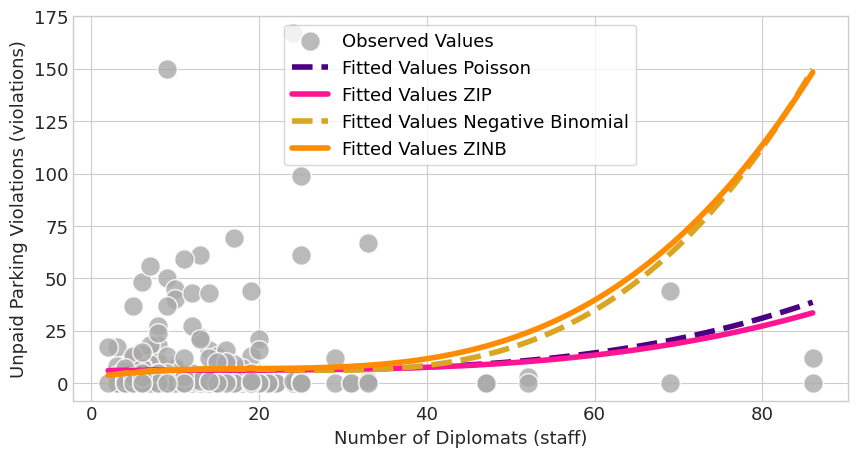

In [14]:
# plotting fitted values for all 4 models, (PR, BN, ZIP and ZINB), considering, as predictor, only the staff
# variable (as to show all 3 predictors we'd need a 4D-graph) and as dependent variable the number of parking 
# violation tickets

plt.figure(figsize=(10,5))
with plt.style.context('seaborn-v0_8-whitegrid'):
    sns.scatterplot(x='staff', y='violations', data=corruption_df,
                    color='darkgrey',
                    s=200, label='Observed Values', alpha=0.8)
    sns.regplot(data=corruption_df, x='staff', y='fitted_poisson', order=3,
                ci=False, scatter=False, color='indigo',
                label='Fitted Values Poisson',
                line_kws={'linewidth': 4, 'linestyle': 'dashed'})
    sns.regplot(data=corruption_df, x='staff', y='fitted_zip', order=3,
                ci=False, scatter = False, color='deeppink',
                label='Fitted Values ZIP',
                line_kws={'linewidth': 4})
    sns.regplot(data=corruption_df, x='staff', y='fitted_neg_binomial', order=3,
                ci=False, scatter = False, color='goldenrod',
                label='Fitted Values Negative Binomial',
                line_kws={'linewidth': 4, 'linestyle': 'dashed'})
    sns.regplot(data=corruption_df, x='staff', y='fitted_zinb', order=3,
                ci=False, scatter=False, color='darkorange',
                label='Fitted Values ZINB',
                line_kws={'linewidth': 4})
plt.xlabel('Number of Diplomats (staff)', fontsize=13)
plt.ylabel('Unpaid Parking Violations (violations)', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(loc='upper center', fontsize=13)
plt.show()

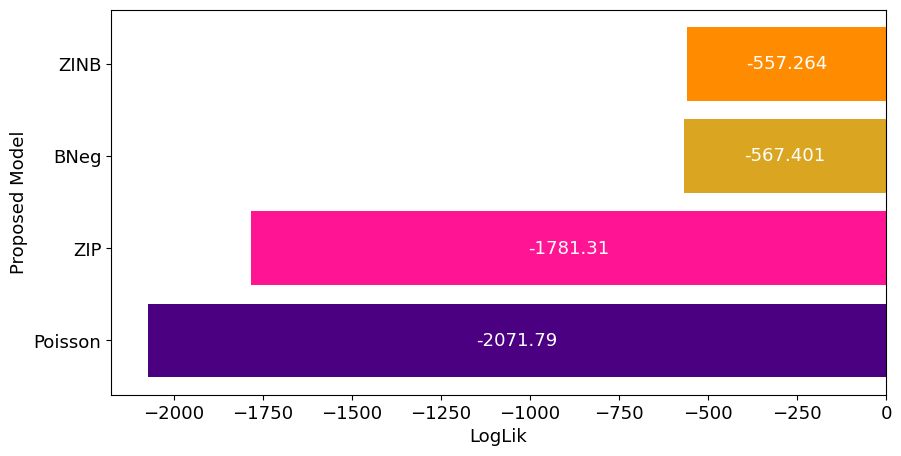

In [17]:
# plotting the comparison between LogLiks of four models (PR, NB, ZIP and ZINB)

llf_df = pd.DataFrame({'model':['Poisson','ZIP','BNeg','ZINB'],
                      'loglik':[poisson_model.llf,
                                zip_model.llf,
                                neg_binomial_model.llf,
                                zinb_model.llf]})

fig, ax = plt.subplots(figsize=(10,5))

c = ['indigo', 'deeppink', 'goldenrod', 'darkorange']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()